<a href="https://colab.research.google.com/github/kiml0v909/SOH_battery/blob/main/battery_SOH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
!wget -q https://github.com/XiuzeZhou/NASA/raw/main/dataset/B0005.mat
!wget -q https://github.com/XiuzeZhou/NASA/raw/main/dataset/B0006.mat
!wget -q https://github.com/XiuzeZhou/NASA/raw/main/dataset/B0007.mat
!wget -q https://github.com/XiuzeZhou/NASA/raw/main/dataset/B0018.mat
!ls -la *.mat

-rw-r--r-- 1 root root 15956874 Aug 17 03:15 B0005.mat
-rw-r--r-- 1 root root 16028159 Aug 17 03:15 B0006.mat
-rw-r--r-- 1 root root 16049460 Aug 17 03:15 B0007.mat
-rw-r--r-- 1 root root  8502218 Aug 17 03:15 B0018.mat


In [14]:
from scipy.io import loadmat

mat = loadmat('B0005.mat') #loadmat으로 matlab 파일을 파이썬 딕셔너리처럼 불러옴
print("최상위 키:", [k for k in mat.keys() if not k.startswith('--')])

battery = mat['B0005'] #mat['B0005']가 실제 데이터 본체
print("battery shape:", battery.shape)
print("필드 이름", battery.dtype.names)

cycles = battery[0,0]['cycle'][0] #matlab 구조라서 [0,0]으로 벗겨줘야 cycle 필드에 접근 가능함
print("총 사이클 개수:", len(cycles)) #cycle 내에 charge/discharge/impendance가 순서대로 들어있는 배열이 있음

최상위 키: ['__header__', '__version__', '__globals__', 'B0005']
battery shape: (1, 1)
필드 이름 ('cycle',)
총 사이클 개수: 616


In [15]:
#discharger 타입인 사이클만 골라내기
discharge_cycles = [c for c in cycles if c['type'][0] == 'discharge']
print("discharge 사이클 개수:", len(discharge_cycles))

#첫 번째 discharge 사이클 안에 뭐가 들어있는지 확인
first = discharge_cycles[0]
data = first['data'][0,0] #[0,0]으로 한 겹 벗겨주기 -> capacity는 배열 형태로 감싸져있기 때문
print("data 안의 필드:", data.dtype.names)

#Capacity 값 꺼내보기
print("첫 사이클 Capacity:", data['Capacity'][0][0])

discharge 사이클 개수: 168
data 안의 필드: ('Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_load', 'Voltage_load', 'Time', 'Capacity')
첫 사이클 Capacity: 1.8564874208181574


In [16]:
#모든 discharge 사이클에서 Capacity만 뽑아서 리스트로 만들기
capacities = []
for c in discharge_cycles:
  cap = c['data'][0,0]['Capacity'][0][0]
  capacities.append(cap)

print("총 Capacity 개수:", len(capacities))
print("처음 5개:", capacities[:5])

#초기 용량 기준으로 SOH(%) 계산
initial_capacity = capacities[0]
soh = [(cap/initial_capacity) * 100 for cap in capacities]

print("처음 5개 SOH(%): ", soh[:5])
print("마지막 5개 SOH(%)", soh[-5:])

총 Capacity 개수: 168
처음 5개: [np.float64(1.8564874208181574), np.float64(1.846327249719927), np.float64(1.8353491942234077), np.float64(1.8352625275821128), np.float64(1.8346455082120419)]
처음 5개 SOH(%):  [np.float64(100.0), np.float64(99.45272071416714), np.float64(98.86138595081705), np.float64(98.85671763794173), np.float64(98.82348178817772)]
마지막 5개 SOH(%) [np.float64(69.67263011532883), np.float64(69.37851440175622), np.float64(69.34884167276275), np.float64(70.5103277055252), np.float64(71.37561578838873)]


   cycle  capacity         soh
0      1  1.856487  100.000000
1      2  1.846327   99.452721
2      3  1.835349   98.861386
3      4  1.835263   98.856718
4      5  1.834646   98.823482
     cycle  capacity        soh
163    164  1.293464  69.672630
164    165  1.288003  69.378514
165    166  1.287453  69.348842
166    167  1.309015  70.510328
167    168  1.325079  71.375616


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


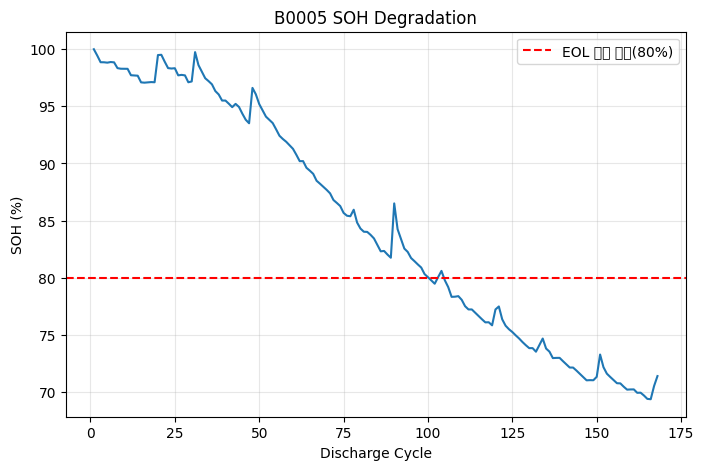

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

#사이클 번호 + SOH를 표로 정리
df = pd.DataFrame({
    'cycle': range(1, len(soh) + 1),
    'capacity' : capacities,
    'soh' : soh
})

print(df.head())
print(df.tail())

#그래프로 열화 곡선 그려보기
plt.figure(figsize=(8,5))
plt.plot(df['cycle'], df['soh'])
plt.xlabel('Discharge Cycle')
plt.ylabel('SOH (%)')
plt.title('B0005 SOH Degradation')
plt.axhline(y=80, color='r', linestyle='--', label= 'EOL 기준 예시(80%)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

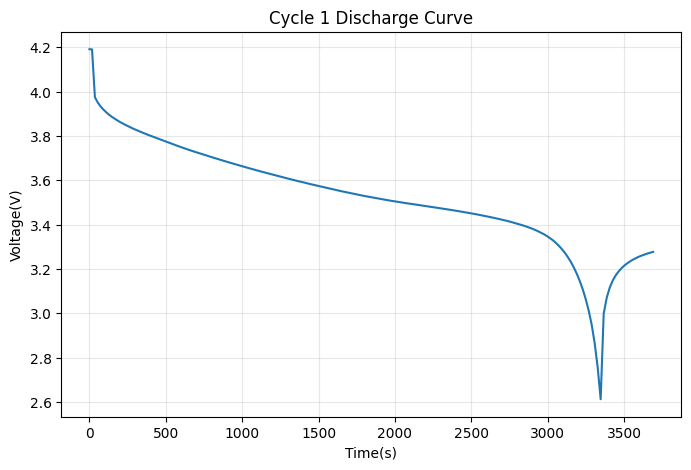

이 사이클 방전에 걸린 총 시간(초): 3690.234


In [18]:
#첫 번째 discharge 사이클의 전압/시간 곡선 그려보기
first_data = discharge_cycles[0]['data'][0,0]

time = first_data['Time'][0]
voltage = first_data['Voltage_measured'][0]

plt.figure(figsize=(8,5))
plt.plot(time, voltage)
plt.xlabel('Time(s)')
plt.ylabel('Voltage(V)')
plt.title('Cycle 1 Discharge Curve')
plt.grid(alpha=0.3)
plt.show()

print("이 사이클 방전에 걸린 총 시간(초):", time[-1])

In [19]:
features = []

for c in discharge_cycles:
  d = c['data'][0,0]

  time = d['Time'][0]
  voltage = d['Voltage_measured'][0]
  temperature = d['Temperature_measured'][0]

  feat = {
      'discharge_time' : time[-1], #총 방전 시간
      'mean_voltage': voltage.mean(), #평균 전압
      'min_voltage' : voltage.min(), #최저 전압
      'mean_temperature' : temperature.mean(),#평균 온도
      'max_temperature' : temperature.max() #최고 온도
  }
  features.append(feat)

feat_df = pd.DataFrame(features)
feat_df['soh'] = soh #앞에서 계산해둔 soh 리스트 붙이기

print(feat_df.head())
print(feat_df.shape)

   discharge_time  mean_voltage  min_voltage  mean_temperature  \
0        3690.234      3.529829     2.612467         32.572328   
1        3672.344      3.537320     2.587209         32.725235   
2        3651.641      3.543737     2.651917         32.642862   
3        3631.563      3.543666     2.592948         32.514876   
4        3629.172      3.542343     2.547420         32.382349   

   max_temperature         soh  
0        38.982181  100.000000  
1        39.033398   99.452721  
2        38.818797   98.861386  
3        38.762305   98.856718  
4        38.665393   98.823482  
(168, 6)


In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#입력(x)과 정답(y)분리
X = feat_df.drop(columns=['soh'])
Y = feat_df['soh']

#앞 80% 사이클로 학습, 뒤 20%로 테스트 (시간 순서 유지, 섞지 않음)
split_idx = int(len(feat_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
Y_train, Y_test = Y.iloc[:split_idx], Y.iloc[split_idx:]

print("학습 데이터 개수:", len(X_train))
print("테스트 데이터 개수:", len(X_test))

#모델1: Linear Regression(베이스라인)
lr = LinearRegression()
lr.fit(X_train, Y_train)
lr_pred = lr.predict(X_test)

#모델 2: Random Forest
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf.fit(X_train, Y_train)
rf_pred = rf.predict(X_test)

#성능 비교
for name, pred in [('Linear Regression', lr_pred),('Random Forest', rf_pred)]:
    rmse = mean_squared_error(Y_test, pred) ** 0.5
    mae = mean_absolute_error(Y_test, pred)
    r2 = r2_score(Y_test, pred)
    print(f"\n{name}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE:  {mae:.3f}")
    print(f" R^2: {r2:.3f}")

학습 데이터 개수: 134
테스트 데이터 개수: 34

Linear Regression
  RMSE: 0.452
  MAE:  0.315
 R^2: 0.857

Random Forest
  RMSE: 2.758
  MAE:  2.515
 R^2: -4.315


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

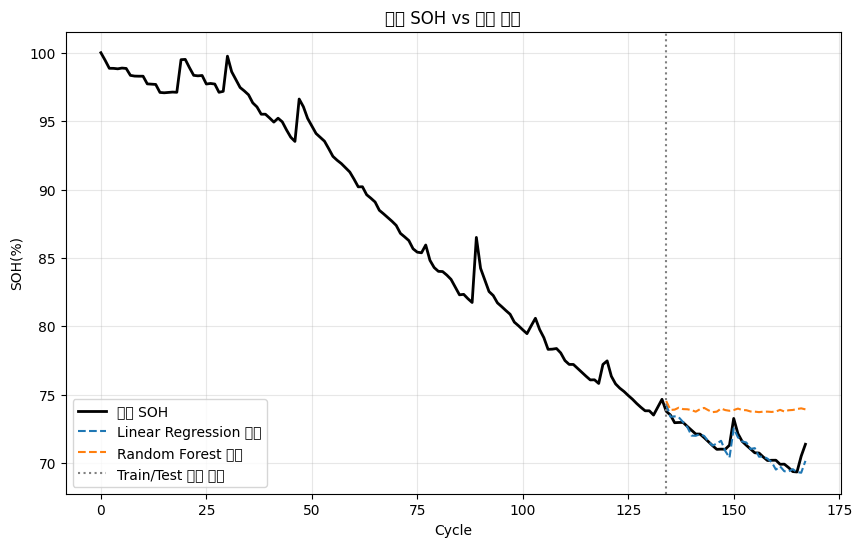

In [21]:
plt.figure(figsize=(10,6))

#전체 실제 SOH (학습+테스트 구간 모두)
plt.plot(range(len(Y)), Y.values, label='실제 SOH', color='black',linewidth=2)

#테스트 구간에 대한 두 모델의 예측
test_range = range(split_idx, len(Y))
plt.plot(test_range, lr_pred, label='Linear Regression 예측', linestyle='--')
plt.plot(test_range, rf_pred, label='Random Forest 예측', linestyle='--')

plt.axvline(x=split_idx, color='gray', linestyle=':', label='Train/Test 분리 지점')
plt.xlabel('Cycle')
plt.ylabel('SOH(%)')
plt.title('실제 SOH vs 모델 예측')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [22]:
#feat_df에 cycle 번호 칼럼 추가 (0부터 시작하므로 +1)
feat_df['cycle_num'] = range(1, len(feat_df)+1)

#X,Y 다시 정의 (cycle_num 포함)
X2 = feat_df.drop(columns=['soh'])
Y2 = feat_df['soh']

X2_train, X2_test = X2.iloc[:split_idx], X2.iloc[split_idx:]
Y2_train, Y2_test = Y2.iloc[:split_idx], Y2.iloc[split_idx:]

#두 모델 재학습
lr2 = LinearRegression()
lr2.fit(X2_train, Y2_train)
lr2_pred = lr2.predict(X2_test)

rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf2.fit(X2_train, Y2_train)
rf2_pred = rf2.predict(X2_test)

#성능 비교
for name, pred in [('Linear Regression (cycle 추가)', lr2_pred), ('Random Forest (cycle 추가)', rf2_pred)]:
    rmse = mean_squared_error(Y2_test, pred) ** 0.5
    r2 = r2_score(Y2_test, pred)
    print(f"{name}: RMSE={rmse:.3f}, R^2={r2:.3f}")

Linear Regression (cycle 추가): RMSE=0.512, R^2=0.817
Random Forest (cycle 추가): RMSE=2.705, R^2=-4.110
